 1 ) Data Collection and Preprocessing

In [65]:
from google.colab import files
uploaded = files.upload()

Saving data-mining.zip to data-mining (5).zip


In [66]:
import os
import re

documents = []
filenames = []

path = "/content/data/data"
all_txt_files = []

# Collect all .txt file paths first
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".txt"):
            all_txt_files.append(os.path.join(root, file))

# Sort files by the number in the filename
all_txt_files = sorted(
    all_txt_files,
    key=lambda x: int(re.findall(r'\d+', os.path.basename(x))[0])
)

# Read files after sorting
for file_path in all_txt_files:
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        documents.append(f.read())
        filenames.append(os.path.basename(file_path))

print(f"Loaded {len(documents)} documents.")
print(filenames[:10])

Loaded 30 documents.
['doc1.txt', 'doc2.txt', 'doc3.txt', 'doc4.txt', 'doc5.txt', 'doc6.txt', 'doc7.txt', 'doc8.txt', 'doc9.txt', 'doc10.txt']


In [67]:
print(len(documents))

30


In [68]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [69]:
#Preprocessing
import re
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Define stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to clean and preprocess text
def preprocess(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # remove punctuation and numbers
    tokens = word_tokenize(text)  # split text into words
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return " ".join(tokens)

# Apply preprocessing to all documents
processed_docs = [preprocess(doc) for doc in documents]

print("Sample processed document:", processed_docs[0])

Sample processed document: gym clean staff friendly equipment modern easy use enjoy working every day place spacious well organized great gym professional trainer machine new good condition


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [70]:
import zipfile
import os

zip_file_path = "/content/data-mining.zip"
extract_dir = "/content/data-mining"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")

'/content/data-mining.zip' unzipped to '/content/data-mining'


In [71]:
# Apply TF-IDF to convert text data into a numerical matrix (documents × terms)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_docs)

print(tfidf_matrix.shape)

(30, 271)


PART 2: INFORMATION RETRIEVAL


In [72]:
import os
import shutil

source_path = "/content/data/data"
target_path = "/content"

for root, dirs, files in os.walk(source_path):
    for file in files:
        if file.endswith(".txt"):
            shutil.copy(os.path.join(root, file), os.path.join(target_path, file))

print("All txt files copied to /content successfully.")
print([f for f in os.listdir("/content") if f.endswith(".txt")][:10])

All txt files copied to /content successfully.
['doc15.txt', 'doc20.txt', 'doc25.txt', 'doc2.txt', 'doc27.txt', 'doc22.txt', 'doc24.txt', 'doc13.txt', 'doc14.txt', 'doc26.txt']


In [73]:
# ============================================
# PART 2: INFORMATION RETRIEVAL
# Topic: Gym Reviews
# Vector Space Model with TF-IDF
# ============================================

import os
import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files
import zipfile

# ========== 1. LOAD DOCUMENTS ==========
# Load all .txt files
path = "/content"
documents = []
filenames = []

for filename in os.listdir(path):
    if filename.endswith('.txt'):
        with open(os.path.join(path, filename), 'r', encoding='utf-8', errors='ignore') as f:
            documents.append(f.read())
            filenames.append(filename)

print(f"\nLoaded {len(documents)} documents")
print(f"Files: {filenames}")


# ========== 2. PREPROCESSING ==========
# Tokenization, stopword removal, cleaning
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

clean_docs = [preprocess(doc) for doc in documents]


# ========== 3. BUILD TF-IDF MATRIX ==========
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(clean_docs)

print(f"\nTF-IDF matrix shape: {tfidf_matrix.shape}")


# ========== 4. RETRIEVAL WITH QUERY ==========
# Query about gym
query = "expensive gym membership not worth it"

# Preprocess query
clean_query = preprocess(query)
query_vector = vectorizer.transform([clean_query])

# Calculate cosine similarity
similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

# Get top results sorted by similarity
top_indices = np.argsort(similarities)[::-1]

# Display results (filenames only, with scores)
print("\n" + "="*50)
print(f"QUERY: '{query}'")
print("="*50)
print("\nTOP RETRIEVED DOCUMENTS:")
print("-"*40)

for i in range(min(10, len(top_indices))):
    idx = top_indices[i]
    print(f"{i+1}. {filenames[idx]} - Similarity: {similarities[idx]:.4f}")


# ========== 5. PRECISION AND RECALL ==========
print("\n" + "="*50)
print("PERFORMANCE EVALUATION")
print("="*50)

# STEP 1: Manually label which documents are RELEVANT to the query
# Replace these with your actual gym-related file names
relevant_docs = {
'doc1.txt','doc2.txt','doc3.txt','doc4.txt','doc5.txt',
'doc6.txt','doc7.txt','doc8.txt','doc9.txt','doc10.txt',
'doc11.txt','doc12.txt','doc13.txt','doc14.txt','doc15.txt'
    # Add all 15 gym-related files here
}

# STEP 2: Get retrieved documents (top 10)
retrieved_docs = set()
for i in range(min(10, len(top_indices))):
    retrieved_docs.add(filenames[top_indices[i]])

# STEP 3: Calculate Precision and Recall
true_positives = len(relevant_docs & retrieved_docs)

precision = true_positives / len(retrieved_docs)
recall = true_positives / len(relevant_docs)

print(f"\nRelevant documents (gym-related): {len(relevant_docs)}")
print(f"Retrieved documents (top 10): {len(retrieved_docs)}")
print(f"True positives: {true_positives}")
print(f"\nPrecision = {precision:.2%}")
print(f"Recall = {recall:.2%}")


Loaded 30 documents
Files: ['doc15.txt', 'doc20.txt', 'doc25.txt', 'doc2.txt', 'doc27.txt', 'doc22.txt', 'doc24.txt', 'doc13.txt', 'doc14.txt', 'doc26.txt', 'doc7.txt', 'doc16.txt', 'doc4.txt', 'doc28.txt', 'doc23.txt', 'doc18.txt', 'doc6.txt', 'doc8.txt', 'doc5.txt', 'doc3.txt', 'doc19.txt', 'doc30.txt', 'doc10.txt', 'doc29.txt', 'doc11.txt', 'doc12.txt', 'doc21.txt', 'doc1.txt', 'doc9.txt', 'doc17.txt']

TF-IDF matrix shape: (30, 272)

QUERY: 'expensive gym membership not worth it'

TOP RETRIEVED DOCUMENTS:
----------------------------------------
1. doc11.txt - Similarity: 0.2283
2. doc8.txt - Similarity: 0.1845
3. doc9.txt - Similarity: 0.1636
4. doc3.txt - Similarity: 0.1506
5. doc4.txt - Similarity: 0.1470
6. doc2.txt - Similarity: 0.1406
7. doc1.txt - Similarity: 0.1382
8. doc7.txt - Similarity: 0.0981
9. doc6.txt - Similarity: 0.0898
10. doc5.txt - Similarity: 0.0862

PERFORMANCE EVALUATION

Relevant documents (gym-related): 15
Retrieved documents (top 10): 10
True positives: 

PART3: Classification


In [74]:
labels = []

for fname in filenames:
    num = int(re.findall(r'\d+', fname)[0])

    if 1 <= num <= 4:
        labels.append("Positive")
    elif 5 <= num <= 8:
        labels.append("Negative")
    elif 9 <= num <= 12:
        labels.append("Positive")
    elif 13 <= num <= 15:
        labels.append("Negative")
    elif 16 <= num <= 23:
        labels.append("Positive")
    elif 24 <= num <= 30:
        labels.append("Negative")

In [75]:
print(len(labels)) # test

30


In [76]:
# Create a structured table that stores each document with its label
import pandas as pd

df = pd.DataFrame({
    "Document_ID": filenames,
    "Document_Text": documents,
    "Label": labels
})

df.head()

,Document_ID,Document_Text,Label
0,doc15.txt,Water fountains are dirty.\nPersonal trainers ...,Negative
1,doc20.txt,The moisturiser absorbs quickly.\nhas a subtle...,Positive
2,doc25.txt,The food tastes bad.\nThe restaurant is dirty....,Negative
3,doc2.txt,\n\nThis gym has excellent equipment and a gre...,Positive
4,doc27.txt,The food is terrible.\nThe place is noisy.\nTh...,Negative


In [77]:
df.to_csv("labeled_data.csv", index=False) # Save the labeled dataset as a CSV file for classification

In [78]:
!ls

 data		        doc10.txt   doc18.txt   doc25.txt   doc4.txt
 data-mining	        doc11.txt   doc19.txt   doc26.txt   doc5.txt
'data-mining (1).zip'   doc12.txt   doc1.txt    doc27.txt   doc6.txt
'data-mining (2).zip'   doc13.txt   doc20.txt   doc28.txt   doc7.txt
'data-mining (3).zip'   doc14.txt   doc21.txt   doc29.txt   doc8.txt
'data-mining (4).zip'   doc15.txt   doc22.txt   doc2.txt    doc9.txt
'data-mining (5).zip'   doc16.txt   doc23.txt   doc30.txt   labeled_data.csv
 data-mining.zip        doc17.txt   doc24.txt   doc3.txt    sample_data


In [79]:
# Convert text labels into numeric values for classification
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(labels)

print(y)

[0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 1 1 1 1]


In [80]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(24, 272) (6, 272)


In [81]:
# Train a Naive Bayes classifier on the training data
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [82]:
# Predict the labels of the test data
y_pred = model.predict(X_test)

print(y_pred)

[1 1 0 0 1 0]


In [83]:
# Evaluate the model performance using accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334



PART 3 )Clustering


Clusters: [0 1 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1]
  Document_ID                                      Document_Text     Label  \
0   doc15.txt  Water fountains are dirty.\nPersonal trainers ...  Negative   
1   doc20.txt  The moisturiser absorbs quickly.\nhas a subtle...  Positive   
2   doc25.txt  The food tastes bad.\nThe restaurant is dirty....  Negative   
3    doc2.txt  \n\nThis gym has excellent equipment and a gre...  Positive   
4   doc27.txt  The food is terrible.\nThe place is noisy.\nTh...  Negative   

   Cluster  
0        0  
1        1  
2        0  
3        1  
4        0  
Accuracy without flipping: 0.9333333333333333
Accuracy with flipping: 0.06666666666666667
Best Cluster Accuracy: 0.9333333333333333


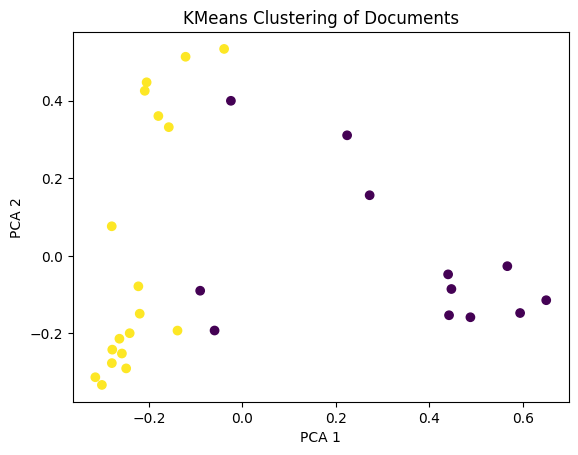

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

# Get cluster labels
clusters = kmeans.labels_

print("Clusters:", clusters)

# Add cluster results to DataFrame
df["Cluster"] = clusters
print(df.head())

# Convert true labels (Positive/Negative) to numeric
true_labels = encoder.transform(labels)

# Compute accuracy in two ways:
# 1) Direct comparison
acc1 = accuracy_score(true_labels, clusters)

# 2) Flipping cluster labels (0 -> 1, 1 -> 0)
flipped_clusters = 1 - clusters
acc2 = accuracy_score(true_labels, flipped_clusters)

# Take the best accuracy
cluster_accuracy = max(acc1, acc2)

print("Accuracy without flipping:", acc1)
print("Accuracy with flipping:", acc2)
print("Best Cluster Accuracy:", cluster_accuracy)

# If flipped version is better, update clusters in DataFrame
if acc2 > acc1:
    clusters = flipped_clusters
    df["Cluster"] = clusters

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(tfidf_matrix.toarray())

# Plot the clustered data
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clustering of Documents")
plt.show()